In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

8000.0


In [26]:

# Load CSV
df = pd.read_csv(
    "/Users/joshpelayo/DATA 5322 02 Statistical Machine Learning 2/Final Project/GamingStudy_data_clean.csv",
    encoding="cp1252"
)

# Need to remove someone with 42054.72844 hours
df = df[~(
    (df["Hours"] >= 8000) &
    (df["streams"] >= 9000)
)].copy()

# Variables to exclude from clustering
exclude_cols = [
    "S. No.",
    "Timestamp",
    "GAD_T",
    "SPIN_T",
    "SWL_T"
]

# Keep numeric variables only
X = df.select_dtypes(include=[np.number]).copy()

# Drop derived totals and ID variables
X = X.drop(
    columns=[col for col in exclude_cols if col in X.columns],
    errors="ignore"
)

print(X.shape)
print(X.columns.tolist())

(13463, 34)
['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'SWL1', 'SWL2', 'SWL3', 'SWL4', 'SWL5', 'Hours', 'highestleague', 'streams', 'SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7', 'SPIN8', 'SPIN9', 'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13', 'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17', 'Narcissism', 'Age']


In [27]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/impute/_base.py:577: UserWarning: Skipping features without any observed values: ['highestleague']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [28]:
pca = PCA(n_components=0.90, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of PCA components:", X_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 33
Number of PCA components: 24
Explained variance: 0.9113315226989488


In [29]:
ks = range(2, 11)

inertias = []
silhouettes = []

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=20
    )
    
    labels = km.fit_predict(X_pca)
    
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_pca, labels)
    )

cluster_scores = pd.DataFrame({
    "k": list(ks),
    "inertia": inertias,
    "silhouette": silhouettes
})

cluster_scores

,k,inertia,silhouette
0,2,319621.358528,0.231197
1,3,297670.390007,0.119379
2,4,280964.912683,0.119741
3,5,269180.073446,0.088677
4,6,261730.716773,0.079439
5,7,256618.144618,0.074452
6,8,252662.689111,0.067917
7,9,248905.250418,0.065642
8,10,246007.733014,0.060758


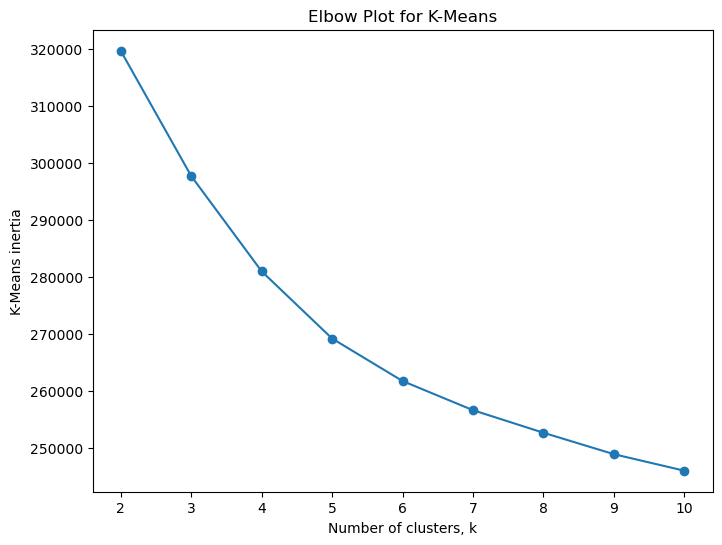

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    cluster_scores["k"],
    cluster_scores["inertia"],
    marker="o"
)

ax.set_xlabel("Number of clusters, k")
ax.set_ylabel("K-Means inertia")
ax.set_title("Elbow Plot for K-Means")

plt.show()

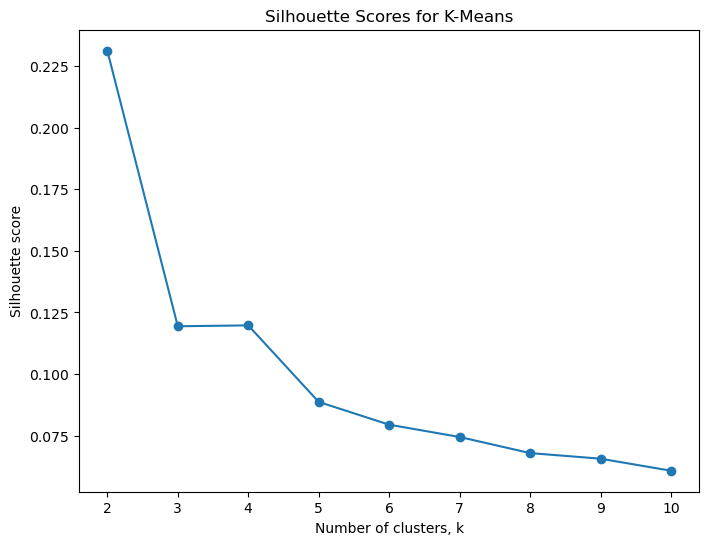

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    cluster_scores["k"],
    cluster_scores["silhouette"],
    marker="o"
)

ax.set_xlabel("Number of clusters, k")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Scores for K-Means")

plt.show()

In [32]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=0,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_pca)

df["cluster"] = cluster_labels

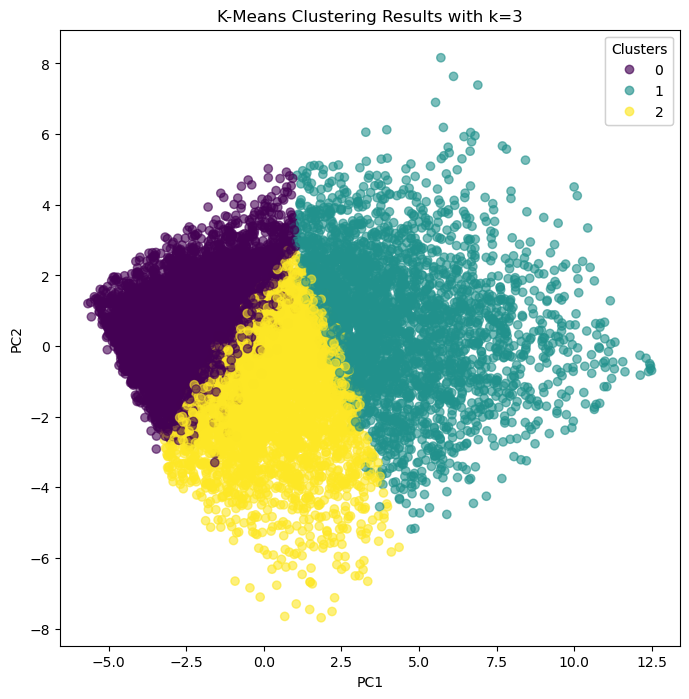

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.6
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"K-Means Clustering Results with k={best_k}")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

ax.add_artist(legend)

plt.show()

In [34]:
df["cluster"].value_counts().sort_index()

cluster
0    5990
1    2981
2    4492
Name: count, dtype: int64

In [35]:
cluster_summary = X.copy()
cluster_summary["cluster"] = cluster_labels

cluster_means = cluster_summary.groupby("cluster").mean().T

cluster_means

cluster,0,1,2
GAD1,0.407846,1.532707,1.019590
GAD2,0.216027,1.362630,0.825913
GAD3,0.458598,1.668568,1.175868
GAD4,0.299332,1.336800,0.883793
GAD5,0.248247,0.852399,0.566118
GAD6,0.537730,1.394498,1.087934
GAD7,0.194658,1.197585,0.710374
SWL1,4.857262,3.031198,2.661843
SWL2,5.551920,3.966454,3.758014
SWL3,5.614357,3.410936,3.274043


,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,...,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3,cluster
3860,4046,42054.72844,0,0,0,1,0,1,0,Very difficult,...,Unknown,Reddit,Singleplayer,Accept,2,12,68.0,NaN,NaN,2


                                                 3860
S. No.                                           4046
Timestamp                                 42054.72844
GAD1                                                0
GAD2                                                0
GAD3                                                0
GAD4                                                1
GAD5                                                0
GAD6                                                1
GAD7                                                0
GADE                                   Very difficult
SWL1                                                4
SWL2                                                1
SWL3                                                2
SWL4                                                3
SWL5                                                2
Game                                League of Legends
Platform                                           PC
Hours                       